# Brachistochrone: Fastest Descent Curves

The brachistochrone problem asks for the curve minimizing travel time under gravity between two points.
With no friction and starting from rest, travel time along a graph $y(x)$ is
$$
T[y] = \int_0^{x_1}\sqrt{\frac{1+y'(x)^2}{2g\,y(x)}}\,dx.
$$
The minimizer is a cycloid (up to scaling and shift), not a straight line.

We compare several curve families and animate particles sliding along them.


## Environment

Numerical quadrature and interpolation are sufficient for visual comparisons.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120


## Reference cycloid-like profile

Construct a base descending profile from cycloidal parametrization.


In [2]:
n = 1800
xmax = 5.0
p = 9
rho = np.linspace(0, 1, p)

t = np.linspace(-np.pi, np.pi, n)
u = t + np.sin(t) + np.pi
v = 1 + np.cos(t)
x = np.linspace(0, xmax, n)
y0 = np.interp(x, u / u.max() * xmax, v)
y0 = y0 - y0.min() + 0.06


## Family of candidate curves

Perturb the baseline with oscillatory modes to compare travel times.


In [3]:
def curve_family(r):
    return y0 + 0.8 * (2 * r - 1) * np.sin(4 * np.pi * x / xmax)

Y = np.stack([curve_family(r) for r in rho], axis=1)
Y = np.maximum(Y, 0.04)


## Time-of-flight computation

Discrete approximation of
$$
T(x)=\int_0^x \sqrt{\frac{1+y'(s)^2}{y(s)}}\,ds
$$
up to a multiplicative constant.


In [4]:
dx = x[1] - x[0]
Yd = np.gradient(Y, dx, axis=0)
U = np.sqrt((1 + Yd**2) / np.maximum(Y, 1e-4))
T = np.cumsum(U * dx, axis=0)
T = np.vstack([np.zeros((1, p)), T[:-1]])

travel = T[-1]
fastest = np.argmin(travel)
print("Fastest curve index:", fastest, "time=", float(travel[fastest]))


Fastest curve index: 4 time= 7.060889487905362


## Static comparison

Display all candidate curves and highlight the fastest one.


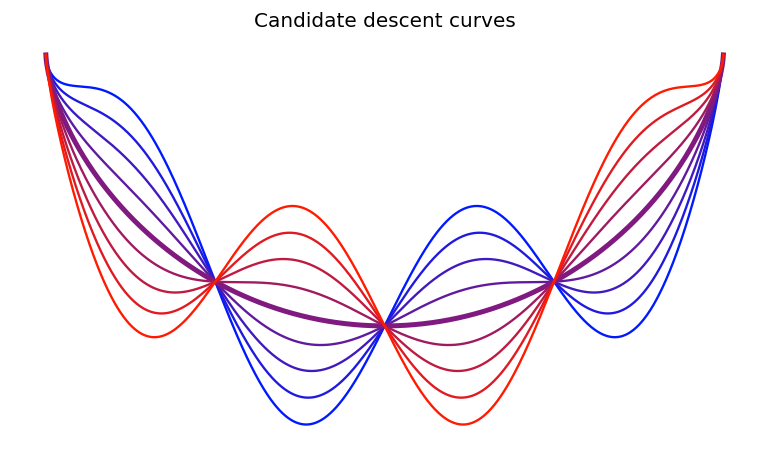

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
for j in range(p):
    s = j / (p - 1)
    lw = 3 if j == fastest else 1.4
    ax.plot(x, 1.8 - Y[:, j], color=(s, 0.1, 1 - s), lw=lw)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Candidate descent curves")
ax.axis("off")
plt.show()


## Sliding particles animation

For each global time $t$, interpolate particle position on each curve.


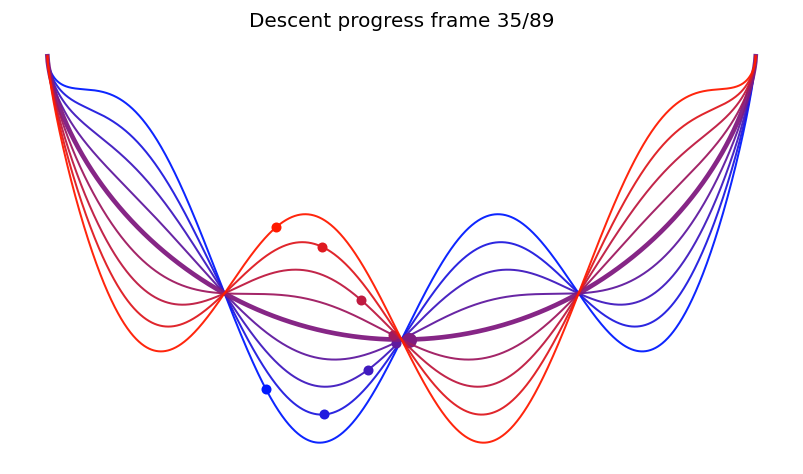

interactive(children=(IntSlider(value=35, description='particle-position', max=89), Output()), _dom_classes=('…

In [6]:
L = np.max(T)
q = 90
tt = np.linspace(0, L, q)
Xt = np.zeros((q, p))
for j in range(p):
    Xt[:, j] = np.interp(tt, T[:, j], x, left=0, right=xmax)
Yt = np.zeros((q, p))
for j in range(p):
    Yt[:, j] = np.interp(Xt[:, j], x, Y[:, j])

def show_time(k=0):
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    for j in range(p):
        s = j / (p - 1)
        lw = 2.8 if j == fastest else 1.2
        ms = 8 if j == fastest else 5
        col = (s, 0.1, 1 - s)
        ax.plot(x, 1.8 - Y[:, j], color=col, lw=lw, alpha=0.95)
        ax.plot(Xt[k, j], 1.8 - Yt[k, j], "o", color=col, ms=ms)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    ax.set_title(f"Descent progress frame {k}/{q-1}")
    plt.show()

# Static call for headless execution (keeps a representative descent-progress frame).
show_time(k=min(35, q-1));

from ipywidgets import interact, IntSlider
interact(show_time, k=IntSlider(min=0, max=q-1, step=1, value=min(35, q-1), description='particle-position'));


## Bibliographical resources

- Johann Bernoulli (1696 challenge and original brachistochrone problem).
- Goldstein, Poole, Safko, *Classical Mechanics*.
- Gelfand and Fomin, *Calculus of Variations*.
